In [17]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [18]:
# Load dataset
df = pd.read_csv(r"C:\Users\divya\OneDrive\Documents\Experiments\Exp-7\Mall_Customers.csv")

# Show first rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [19]:
# Check missing values
print(df.isnull().sum())

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


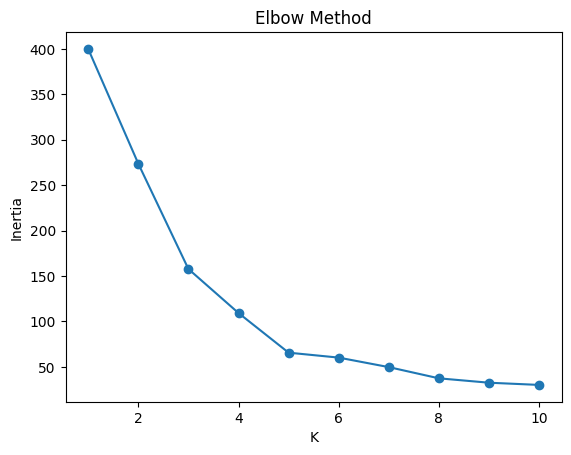

In [20]:
# Find optimal K using inertia
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Plot graph
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [21]:
# Apply KMeans with K=5
kmeans = KMeans(n_clusters=5, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

# Add cluster column
df['KMeans_Cluster'] = k_labels

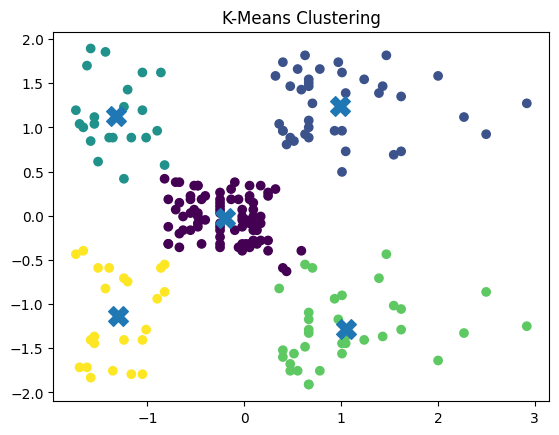

In [22]:
# Plot clusters
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=k_labels)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, marker='X')

plt.title("K-Means Clustering")
plt.show()

In [23]:
# Silhouette score
print("KMeans Score:", silhouette_score(X_scaled, k_labels))

KMeans Score: 0.5546571631111091


In [24]:
# Mean values per cluster (only numeric columns)
print(df.groupby('KMeans_Cluster').mean(numeric_only=True))

                CustomerID        Age  Annual Income (k$)  \
KMeans_Cluster                                              
0                86.320988  42.716049           55.296296   
1               162.000000  32.692308           86.538462   
2                23.090909  25.272727           25.727273   
3               164.371429  41.114286           88.200000   
4                23.000000  45.217391           26.304348   

                Spending Score (1-100)  
KMeans_Cluster                          
0                            49.518519  
1                            82.128205  
2                            79.363636  
3                            17.114286  
4                            20.913043  


In [25]:
# Fit GMM model
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# Predict clusters
g_labels = gmm.predict(X_scaled)

# Add column
df['GMM_Cluster'] = g_labels

In [26]:
# Show probability of clusters
print(gmm.predict_proba(X_scaled)[:5])

[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


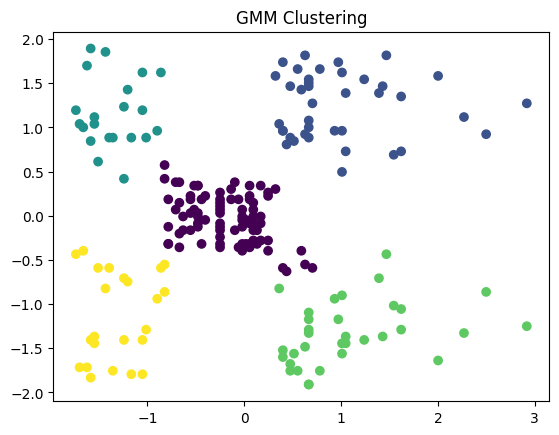

In [27]:
# Plot GMM clusters
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=g_labels)
plt.title("GMM Clustering")
plt.show()

In [28]:
# Print evaluation metrics
print("Log Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("GMM Score:", silhouette_score(X_scaled, g_labels))

Log Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
GMM Score: 0.5536892843811245


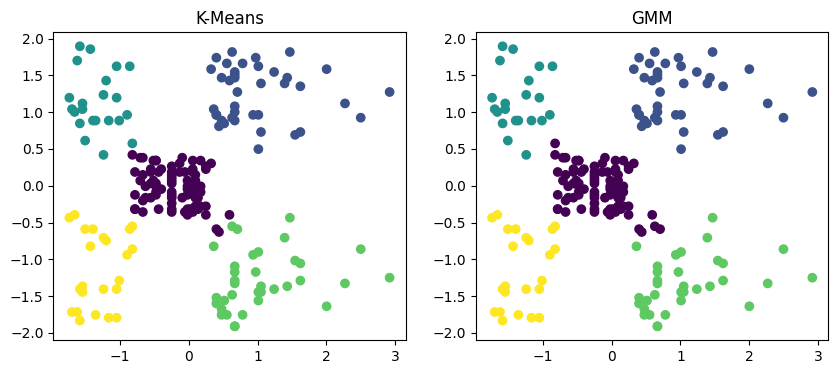

In [29]:
# Compare KMeans and GMM
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=k_labels)
plt.title("K-Means")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=g_labels)
plt.title("GMM")

plt.show()

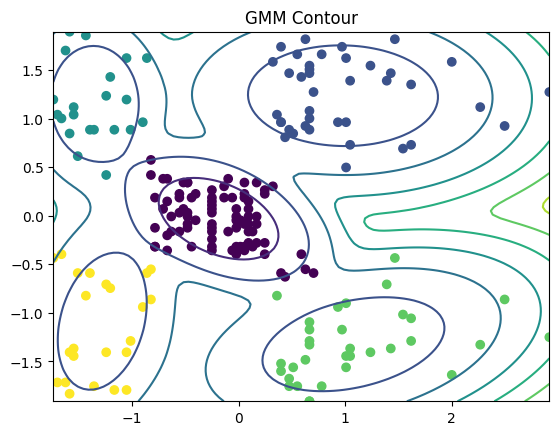

In [30]:
# Create contour plot
x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
Xg, Yg = np.meshgrid(x, y)

XX = np.array([Xg.ravel(), Yg.ravel()]).T
Z = -gmm.score_samples(XX)
Z = Z.reshape(Xg.shape)

plt.contour(Xg, Yg, Z)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=g_labels)
plt.title("GMM Contour")
plt.show()